# Video Summarisation via KMeans Clustering

Automatically selects a compact set of **keyframes** that best represent the visual content of a video.  
The pipeline computes per-frame **BGR colour histograms** as compact visual features and clusters
them with **KMeans**. The frame nearest each cluster centroid becomes a keyframe.

**Dataset context:** Developed for the
[HyperKvasir](https://osf.io/mh9sj/) micro-capsule endoscopy dataset, but works on any `.mp4` / `.avi` video.

---
### Memory-efficient two-pass design

Long videos (hours of footage) cannot fit in RAM as decoded frames.  
This pipeline never accumulates frames:

```
Pass 1 — stream video → compute histogram per frame → discard frame → KMeans on histograms
Pass 2 — seek to selected indices → extract only the keyframes
```

| Metric | Naïve (store all frames) | This pipeline |
|---|---|---|
| 2 h video @ 25 fps, rate=5 | ~44 GB peak RAM | ~10 MB peak RAM |
| Scales to any length? | No | Yes |

> **Format conversion (if needed)**  
> Legacy AVI files (VC-1 codec) should be converted first:
> ```bash
> ffmpeg -i input.avi -c:v libx264 -crf 23 output.mp4
> ```

In [1]:
import os
import shutil
import numpy as np
import cv2
from pathlib import Path
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
%matplotlib inline

## Configuration

| Parameter | Description |
|---|---|
| `VIDEO_PATH` | Path to the input video file |
| `OUTPUT_DIR` | Directory where keyframe JPEGs are saved |
| `SAMPLING_RATE` | Process every N-th frame — higher is faster, coarser |
| `SUMMARY_PCT` | % of sampled frames to keep as keyframes |
| `NUM_BINS` | Histogram bins per BGR channel → `3 × NUM_BINS`-dim feature vector |

In [2]:
VIDEO_PATH    = "Dataset/04a78ef00c5245e0.mp4"  # <-- set this
# VIDEO_PATH    = "Dataset/hyperkvasir/0220d11b-ab12-4b02-93ce-5d7c205c7043.avi"  # <-- set this
OUTPUT_DIR    = "keyframes"
SAMPLING_RATE = 5    # sample every Nth frame
SUMMARY_PCT   = 50   # % of sampled frames to keep
NUM_BINS      = 32   # histogram bins per BGR channel

## Pass 1 — Stream Histograms

The video is read **once, sequentially**. Each sampled frame's BGR colour histogram is computed
immediately and the frame is discarded — only the small feature vector is kept.  
Peak RAM during this step is a **single decoded frame** plus the growing histogram matrix.

In [3]:
def stream_histograms(video_path, sampling_rate=5, num_bins=16):
    """
    Single-pass histogram extraction — no frames are kept in memory.
    Returns:
        hist_matrix     : (N, 3*num_bins) float32 array
        sampled_indices : list of original video frame indices
    """
    video_path = str(Path(video_path))   # normalise: strip trailing slashes, fix separators
    if not Path(video_path).is_file():
        raise FileNotFoundError(f"Video file not found: {video_path}")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"OpenCV could not open: {video_path}")

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    print(f"  {os.path.basename(video_path)}: {total} frames @ {fps:.1f} fps")

    hists, sampled_indices = [], []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % sampling_rate == 0:
            feat = np.concatenate([
                cv2.calcHist([frame], [c], None, [num_bins], [0, 256]).flatten()
                for c in range(3)
            ])
            hists.append(feat)
            sampled_indices.append(frame_idx)
        frame_idx += 1

    cap.release()
    hist_matrix = np.stack(hists).astype(np.float32)
    print(f"  Sampled {len(sampled_indices)} frames — histogram matrix: {hist_matrix.shape} "
          f"({hist_matrix.nbytes / 1e6:.1f} MB)")
    return hist_matrix, sampled_indices

## KMeans Clustering — Select Keyframe Indices

KMeans partitions the histogram matrix into `n_clusters` groups.  
For each cluster the frame with the **smallest distance to its centroid** is the most
representative frame for that visual region of the video.  
Only the selected **frame indices** are returned — no pixel data yet.

In [4]:
def cluster_and_select(hist_matrix, sampled_indices, summary_pct=15):
    """
    Fit KMeans on the histogram matrix and return the original video frame
    indices of the frame closest to each cluster centroid.
    """
    n_clusters = max(1, int(summary_pct * len(sampled_indices) / 100))
    print(f"  Fitting KMeans: {len(sampled_indices)} samples → {n_clusters} clusters")

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(hist_matrix)

    dist = kmeans.transform(hist_matrix)   # (n_samples, n_clusters)
    # index into sampled_indices (deduplicated, chronological order)
    best_sample_idx = sorted(set(int(np.argmin(dist[:, c])) for c in range(n_clusters)))
    keyframe_video_indices = [sampled_indices[i] for i in best_sample_idx]

    print(f"  Selected {len(keyframe_video_indices)} unique keyframe indices")
    return keyframe_video_indices

## Pass 2 — Extract Keyframes

The video is opened a second time. `cv2.CAP_PROP_POS_FRAMES` seeks directly to each selected
index so only the chosen frames are decoded — no sequential scan needed.

In [5]:
def extract_keyframes(video_path, keyframe_video_indices):
    """Seek to each selected index and return the decoded frames."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"Cannot open video: {video_path}")

    keyframes = []
    for vid_idx in keyframe_video_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, vid_idx)
        ret, frame = cap.read()
        if ret:
            keyframes.append(frame)

    cap.release()
    print(f"  Decoded {len(keyframes)} keyframes")
    return keyframes

## Save & Visualise

Keyframes are written to `OUTPUT_DIR` as numbered JPEGs (filename encodes the original frame index)
and displayed inline for inspection.

In [6]:
def save_keyframes(keyframes, keyframe_indices, output_dir):
    """Write keyframes as JPEGs; recreates output_dir on each run."""
    out = Path(output_dir)
    if out.exists():
        shutil.rmtree(out)
    out.mkdir(parents=True)
    for i, (frame, vid_idx) in enumerate(zip(keyframes, keyframe_indices)):
        cv2.imwrite(str(out / f"keyframe_{i:03d}_f{vid_idx}.jpg"), frame)
    print(f"  Saved {len(keyframes)} keyframes → '{output_dir}'")


def display_keyframes(keyframes, keyframe_indices, cols=4):
    """Display keyframes in a grid; titles show original frame numbers."""
    n    = len(keyframes)
    # rows = (n + cols - 1) // cols
    rows = 5
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = np.array(axes).flatten()

    for i, (frame, vid_idx) in enumerate(zip(keyframes[:cols*rows], keyframe_indices[:cols*rows])):
        axes[i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Frame {vid_idx}", fontsize=9)
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("KMeans Video Summary — Keyframes", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

## Run the Pipeline

Set `VIDEO_PATH` in the **Configuration** cell above, then run all cells.

=== Pass 1: Stream histograms ===
  04a78ef00c5245e0.mp4: 50986 frames @ 30.0 fps
  Sampled 10198 frames — histogram matrix: (10198, 96) (3.9 MB)

=== KMeans clustering ===
  Fitting KMeans: 10198 samples → 5099 clusters
  Selected 5099 unique keyframe indices

=== Pass 2: Extract keyframes ===
  Decoded 5099 keyframes

=== Save & display ===
  Saved 5099 keyframes → 'keyframes'


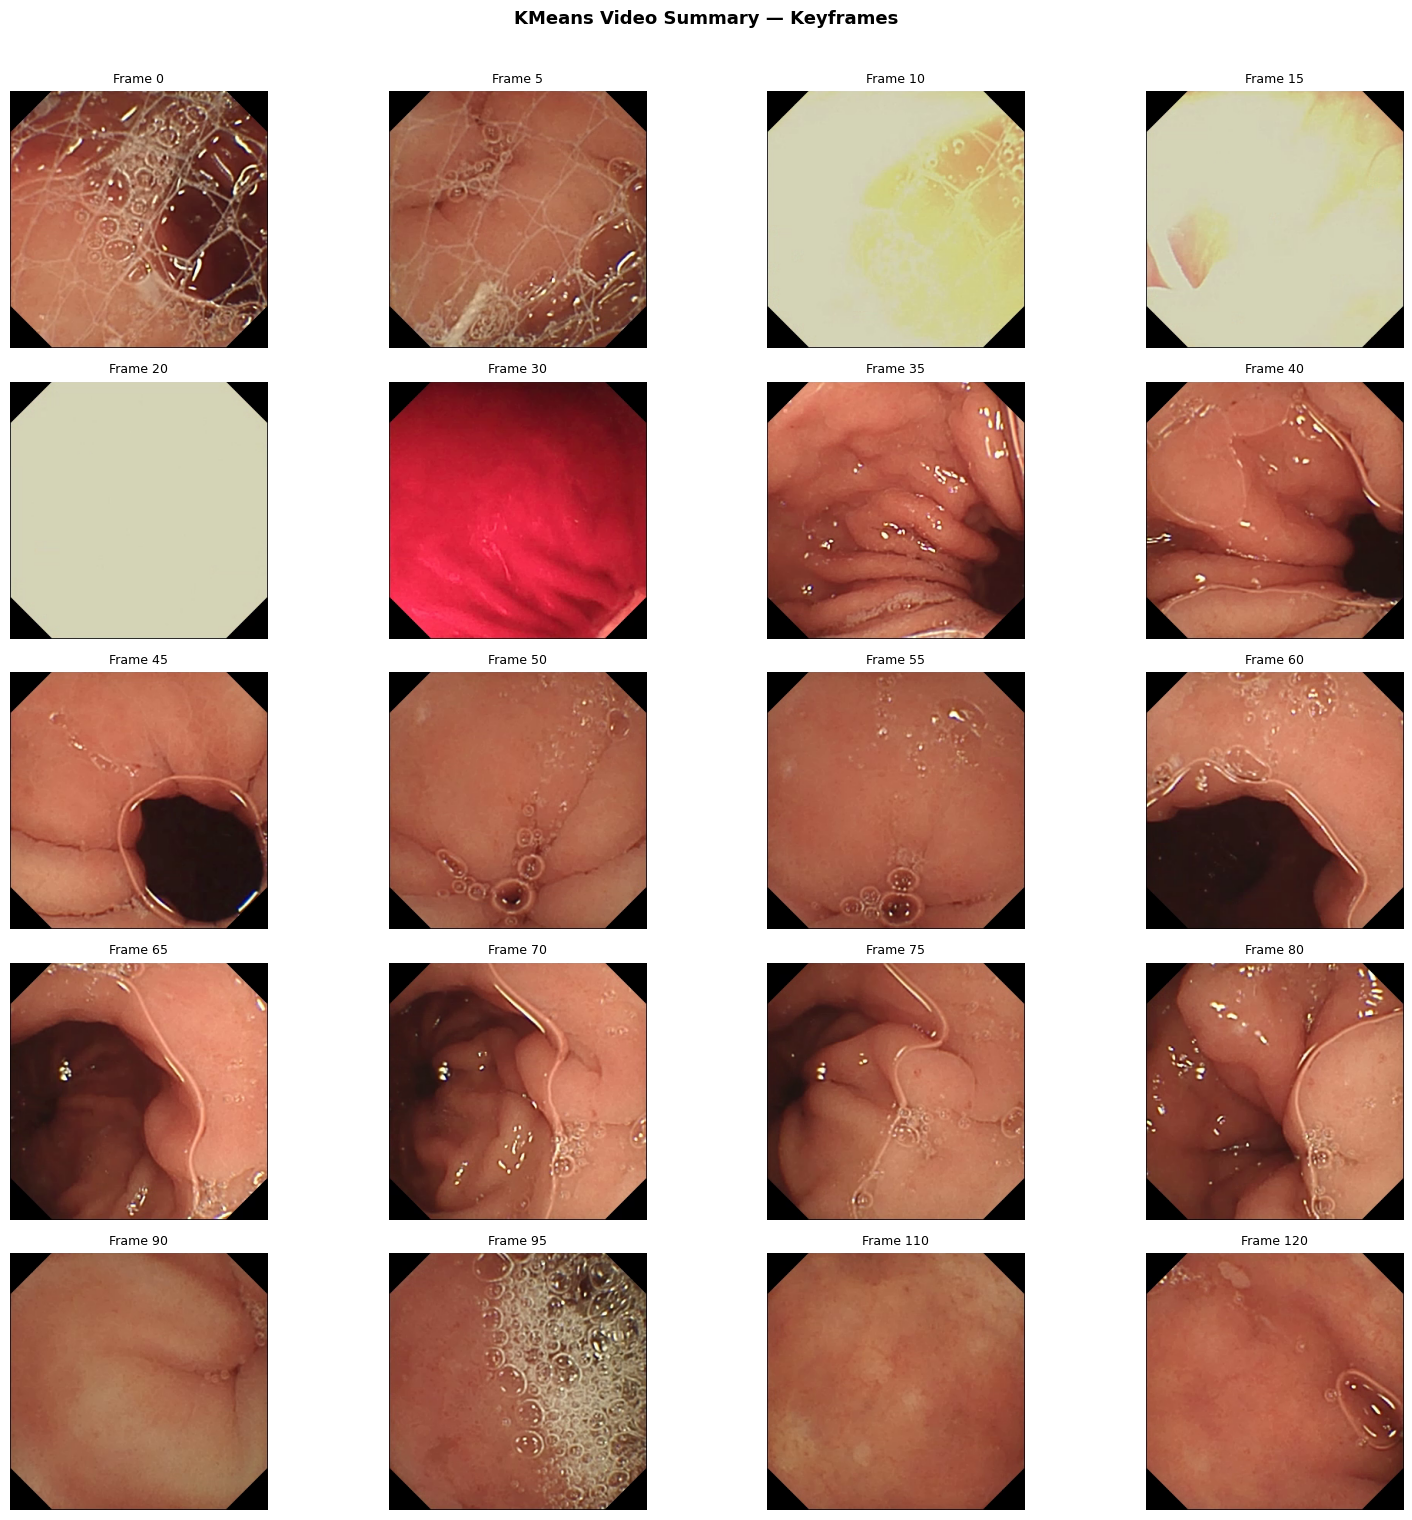

In [7]:
print("=== Pass 1: Stream histograms ===")
hist_matrix, sampled_indices = stream_histograms(VIDEO_PATH, SAMPLING_RATE, NUM_BINS)

print("\n=== KMeans clustering ===")
keyframe_video_indices = cluster_and_select(hist_matrix, sampled_indices, SUMMARY_PCT)

print("\n=== Pass 2: Extract keyframes ===")
keyframes = extract_keyframes(VIDEO_PATH, keyframe_video_indices)

print("\n=== Save & display ===")
save_keyframes(keyframes, keyframe_video_indices, OUTPUT_DIR)
display_keyframes(keyframes, keyframe_video_indices)